# 30 RoBERTa Baseline Sanity Check

Goal: verify that our evaluation and inference framework can reproduce the original RoBERTa baseline behavior closely enough to validate the method setup.


In [1]:
# Cell 0: Config, paths, and run toggles.
import os
import re
import ast
import json
import subprocess
from pathlib import Path

PROJECT_ROOT = Path('/home/rameyjm7/workspace/llamafactory-gemma-lora')
EXPRESS_ROOT = PROJECT_ROOT / 'express-emotion-recognition'
ENV_FILE = PROJECT_ROOT / 'env.txt'

MODEL_NAME_OR_PATH = 'FacebookAI/roberta-base'
MODEL_ID = 'roberta_base_sanity'
ROBERTA_CACHE_DIR = PROJECT_ROOT / 'outputs' / 'hf_cache' / 'hf_cache_roberta_base'

# Set True to actually rerun baseline inference with base RoBERTa (can take a while on full set).
REPRODUCE_INFERENCE = True

# Use full eval set by default to compare apples-to-apples with authors baseline.
EVAL_ROWS = None
MAX_LENGTH = 512

OUT_DIR = PROJECT_ROOT / 'outputs' / 'metrics' / 'sanity_roberta_baseline'
OUT_DIR.mkdir(parents=True, exist_ok=True)

AUTHORS_RESULT_PATH = EXPRESS_ROOT / 'results' / 'roberta-base.csv'
EVAL_INPUT_PATH = OUT_DIR / 'roberta_baseline_eval_input.csv'
RAW_OUTPUT_PATH = OUT_DIR / 'roberta_baseline_reproduced_raw.csv'
CLEAN_OUTPUT_PATH = OUT_DIR / 'roberta_baseline_reproduced_clean.csv'
COMPARE_JSON_PATH = OUT_DIR / 'roberta_baseline_compare.json'

print('REPRODUCE_INFERENCE =', REPRODUCE_INFERENCE)
print('AUTHORS_RESULT_PATH =', AUTHORS_RESULT_PATH)
print('OUT_DIR =', OUT_DIR)
print('ROBERTA_CACHE_DIR =', ROBERTA_CACHE_DIR)


REPRODUCE_INFERENCE = True
AUTHORS_RESULT_PATH = /home/rameyjm7/workspace/llamafactory-gemma-lora/express-emotion-recognition/results/roberta-base.csv
OUT_DIR = /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/metrics/sanity_roberta_baseline
ROBERTA_CACHE_DIR = /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/hf_cache/hf_cache_roberta_base


In [2]:
# Cell 1: Helpers (token load, command runner, metric parser).
import pandas as pd


def load_hf_token_from_env_file(path: Path) -> str:
    if not path.exists():
        raise FileNotFoundError(f'Env file not found: {path}')

    token = ''
    for raw in path.read_text(encoding='utf-8').splitlines():
        line = raw.strip()
        if not line or line.startswith('#'):
            continue
        if line.startswith('HF_TOKEN='):
            token = line.split('=', 1)[1].strip().strip('"').strip("'")
            break

    if not token:
        raise ValueError(f'HF_TOKEN not found or empty in {path}')
    return token


def run_cmd(cmd, cwd=None, env=None, check=True):
    printable = ' '.join(str(x) for x in cmd)
    print(f'$ {printable}')
    merged_env = os.environ.copy()
    if env:
        merged_env.update(env)

    proc = subprocess.Popen(
        [str(x) for x in cmd],
        cwd=str(cwd) if cwd else None,
        env=merged_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    lines = []
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end='')
        lines.append(line)

    rc = proc.wait()
    out = ''.join(lines)
    if check and rc != 0:
        tail = ''.join(lines[-120:])
        raise RuntimeError(
            f'Command failed ({rc}): {printable}\n'
            f'--- Last output lines ---\n{tail}'
        )
    return out


def parse_eval_metrics(stdout_text):
    metrics = {}
    for key in ['VRate', 'AccL', 'AccV', 'F1V', 'AccV-2']:
        m = re.search(rf'{re.escape(key)}\s*=\s*([0-9]*\.?[0-9]+)', stdout_text)
        if m:
            metrics[key] = float(m.group(1))
    return metrics


HF_TOKEN = load_hf_token_from_env_file(ENV_FILE)
os.environ['HF_TOKEN'] = HF_TOKEN
print('HF token loaded from env file')


HF token loaded from env file


In [3]:
# Cell 2: Evaluate authors' baseline file with project evaluation script.
authors_eval_stdout = run_cmd(
    [
        'python', str(EXPRESS_ROOT / 'src' / 'evaluation' / 'result-evaluation.py'),
        '--result_path', str(AUTHORS_RESULT_PATH),
        '--breakdowns_path', str(EXPRESS_ROOT / 'data' / 'lexicon-decomposition.csv'),
    ],
    cwd=PROJECT_ROOT,
    check=True,
)
authors_metrics = parse_eval_metrics(authors_eval_stdout)
print('Authors baseline metrics:', authors_metrics)


$ python /home/rameyjm7/workspace/llamafactory-gemma-lora/express-emotion-recognition/src/evaluation/result-evaluation.py --result_path /home/rameyjm7/workspace/llamafactory-gemma-lora/express-emotion-recognition/results/roberta-base.csv --breakdowns_path /home/rameyjm7/workspace/llamafactory-gemma-lora/express-emotion-recognition/data/lexicon-decomposition.csv
Evaluating: /home/rameyjm7/workspace/llamafactory-gemma-lora/express-emotion-recognition/results/roberta-base.csv
Total valid rows = 35176
VRate = 0.9991471457812144

Lexicon Accuracy: 100%|██████████| 35146/35146 [00:00<00:00, 224004.01it/s]

Vector Accuracy: 100%|██████████| 35146/35146 [02:36<00:00, 224.48it/s]
AccL = 0.32435064935064933
AccV = 0.37353896103896106
F1V = 0.6614207048379555
AccV-2 = 0.8257855956078884
Authors baseline metrics: {'VRate': 0.9991471457812144, 'AccL': 0.32435064935064933, 'AccV': 0.37353896103896106, 'F1V': 0.6614207048379555, 'AccV-2': 0.8257855956078884}


In [4]:
# Cell 3: Build eval input from authors baseline rows.
auth_df = pd.read_csv(AUTHORS_RESULT_PATH)
auth_eval_df = auth_df[['segment', 'labels', 'number_of_labels']].copy()
if EVAL_ROWS is not None:
    auth_eval_df = auth_eval_df.head(int(EVAL_ROWS))
auth_eval_df.to_csv(EVAL_INPUT_PATH, index=False)

print('Saved eval input:', EVAL_INPUT_PATH)
print('Rows:', len(auth_eval_df))
display(auth_eval_df.head(2))


Saved eval input: /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/metrics/sanity_roberta_baseline/roberta_baseline_eval_input.csv
Rows: 35176


,segment,labels,number_of_labels
0,I feel <mask> by others admiration. If other a...,"['disgusted', 'disgusted']",2
1,"Question, is there a resource for novices that...",['confident'],1


In [5]:
# Cell 4: Reproduce baseline inference with base RoBERTa (no LoRA adapter).
if REPRODUCE_INFERENCE:
    import torch
    from tqdm.auto import tqdm
    from transformers import AutoTokenizer, AutoModelForMaskedLM

    eval_df = pd.read_csv(EVAL_INPUT_PATH)

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME_OR_PATH,
        token=HF_TOKEN,
        cache_dir=str(ROBERTA_CACHE_DIR),
        use_fast=True,
    )
    model = AutoModelForMaskedLM.from_pretrained(
        MODEL_NAME_OR_PATH,
        token=HF_TOKEN,
        cache_dir=str(ROBERTA_CACHE_DIR),
    )

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    model.eval()

    mask_token = tokenizer.mask_token
    if mask_token is None:
        raise ValueError('Tokenizer has no mask token; cannot run MLM inference.')

    def normalize_pred_token(text):
        return re.sub(r'\s+', ' ', str(text)).strip().lower()

    def predict_mask_list(segment, num_labels):
        working_text = str(segment)
        target_n = int(num_labels)
        preds = []

        for _ in range(target_n):
            if mask_token not in working_text:
                break

            enc = tokenizer(
                working_text,
                return_tensors='pt',
                truncation=True,
                max_length=MAX_LENGTH,
            )
            enc = {k: v.to(device) for k, v in enc.items()}

            mask_positions = (enc['input_ids'][0] == tokenizer.mask_token_id).nonzero(as_tuple=False)
            if len(mask_positions) == 0:
                break

            pos = int(mask_positions[0].item())
            with torch.inference_mode():
                logits = model(**enc).logits[0, pos]
            pred_id = int(torch.argmax(logits).item())
            pred_word = normalize_pred_token(tokenizer.decode([pred_id], skip_special_tokens=True))
            if not pred_word:
                pred_word = 'neutral'

            preds.append(pred_word)
            working_text = working_text.replace(mask_token, pred_word, 1)

        if len(preds) != target_n:
            return 'INVALID OUTPUT'
        return str(preds)

    outputs = []
    for row in tqdm(eval_df.itertuples(index=False), total=len(eval_df), desc='RoBERTa baseline reproduction'):
        outputs.append(predict_mask_list(row.segment, row.number_of_labels))

    raw_df = eval_df.copy()
    raw_df['output'] = outputs
    raw_df.to_csv(RAW_OUTPUT_PATH, index=False)

    print('Saved raw reproduced outputs to:', RAW_OUTPUT_PATH)
    print('Rows:', len(raw_df))
else:
    print('Skipping inference reproduction (REPRODUCE_INFERENCE=False).')



I0000 00:00:1774985830.102929 3594763 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774985830.141100 3594763 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774985836.052324 3594763 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


RoBERTa baseline reproduction:   0%|          | 0/35176 [00:00<?, ?it/s]

Saved raw reproduced outputs to: /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/metrics/sanity_roberta_baseline/roberta_baseline_reproduced_raw.csv
Rows: 35176


In [6]:
# Cell 5: Clean and evaluate reproduced outputs.
if RAW_OUTPUT_PATH.exists():
    _ = run_cmd(
        [
            'python', str(EXPRESS_ROOT / 'src' / 'evaluation' / 'result-cleaning.py'),
            '--input', str(RAW_OUTPUT_PATH),
            '--output', str(CLEAN_OUTPUT_PATH),
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )

    repro_eval_stdout = run_cmd(
        [
            'python', str(EXPRESS_ROOT / 'src' / 'evaluation' / 'result-evaluation.py'),
            '--result_path', str(CLEAN_OUTPUT_PATH),
            '--breakdowns_path', str(EXPRESS_ROOT / 'data' / 'lexicon-decomposition.csv'),
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )
    repro_metrics = parse_eval_metrics(repro_eval_stdout)
    print('Reproduced baseline metrics:', repro_metrics)
else:
    repro_metrics = {}
    print('No raw reproduced outputs found yet. Run Cell 4 first.')


$ python /home/rameyjm7/workspace/llamafactory-gemma-lora/express-emotion-recognition/src/evaluation/result-cleaning.py --input /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/metrics/sanity_roberta_baseline/roberta_baseline_reproduced_raw.csv --output /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/metrics/sanity_roberta_baseline/roberta_baseline_reproduced_clean.csv
Valid rows: 35146 / 35176
Cleaned file saved to: /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/metrics/sanity_roberta_baseline/roberta_baseline_reproduced_clean.csv
$ python /home/rameyjm7/workspace/llamafactory-gemma-lora/express-emotion-recognition/src/evaluation/result-evaluation.py --result_path /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/metrics/sanity_roberta_baseline/roberta_baseline_reproduced_clean.csv --breakdowns_path /home/rameyjm7/workspace/llamafactory-gemma-lora/express-emotion-recognition/data/lexicon-decomposition.csv
Evaluating: /home/rameyjm7/workspace/llamafact

In [7]:
# Cell 6: Compare authors vs reproduced metrics and save summary JSON.
keys = ['VRate', 'AccL', 'AccV', 'F1V', 'AccV-2']
comparison = {
    'authors': {k: authors_metrics.get(k) for k in keys},
    'reproduced': {k: repro_metrics.get(k) for k in keys},
    'delta': {},
}
for k in keys:
    a = comparison['authors'].get(k)
    b = comparison['reproduced'].get(k)
    comparison['delta'][k] = (b - a) if (a is not None and b is not None) else None

COMPARE_JSON_PATH.write_text(json.dumps(comparison, indent=2), encoding='utf-8')
print('Saved comparison:', COMPARE_JSON_PATH)
print(json.dumps(comparison, indent=2))


Saved comparison: /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/metrics/sanity_roberta_baseline/roberta_baseline_compare.json
{
  "authors": {
    "VRate": 0.9991471457812144,
    "AccL": 0.32435064935064933,
    "AccV": 0.37353896103896106,
    "F1V": 0.6614207048379555,
    "AccV-2": 0.8257855956078884
  },
  "reproduced": {
    "VRate": 0.9991471457812144,
    "AccL": 0.3225829725829726,
    "AccV": 0.3727994227994228,
    "F1V": 0.6615357710306422,
    "AccV-2": 0.8256375063208842
  },
  "delta": {
    "VRate": 0.0,
    "AccL": -0.0017676767676767513,
    "AccV": -0.0007395382395382621,
    "F1V": 0.00011506619268675244,
    "AccV-2": -0.0001480892870042716
  }
}


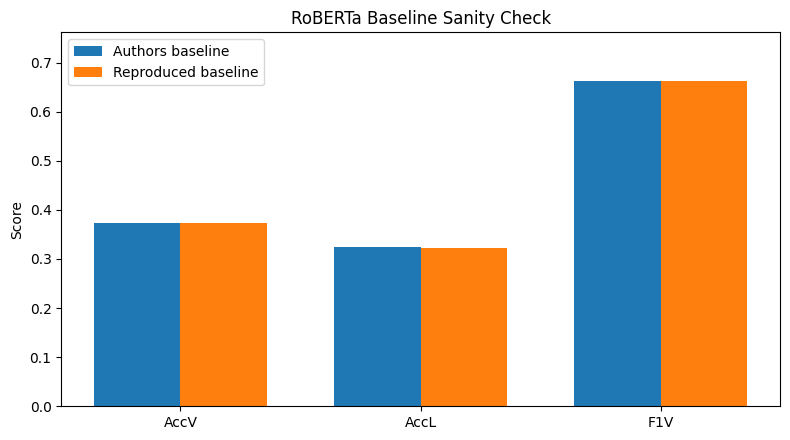

In [8]:
# Cell 7: Quick chart (authors vs reproduced) for AccV/AccL/F1V.
import matplotlib.pyplot as plt

plot_keys = ['AccV', 'AccL', 'F1V']
a_vals = [authors_metrics.get(k, 0.0) for k in plot_keys]
r_vals = [repro_metrics.get(k, 0.0) for k in plot_keys]

x = range(len(plot_keys))
width = 0.36

plt.figure(figsize=(8, 4.5))
plt.bar([i - width/2 for i in x], a_vals, width=width, label='Authors baseline')
plt.bar([i + width/2 for i in x], r_vals, width=width, label='Reproduced baseline')
plt.xticks(list(x), plot_keys)
plt.ylim(0, max(0.5, max(a_vals + r_vals) + 0.1))
plt.title('RoBERTa Baseline Sanity Check')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()
